<a href="https://colab.research.google.com/github/MakwBansari/EduNetGTU/blob/main/day6_11_07_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Linear Regression**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

In [2]:
from google.colab import files

uploaded = files.upload()

Saving complete_renewable_energy_dataset.csv to complete_renewable_energy_dataset.csv


In [3]:
renewable_df = pd.read_csv("complete_renewable_energy_dataset.csv")

renewable_df.head()

print("Shape of Dataset")
print(renewable_df.shape)

print("\nColumns")
print(renewable_df.columns)

print("\nInformation")
print(renewable_df.info())

print("\nDescription")
print(renewable_df.describe())

print("\nMissing Values")
print(renewable_df.isnull().sum())

print("\nDuplicate Rows")
print(renewable_df.duplicated().sum())

Shape of Dataset
(2500, 56)

Columns
Index(['Country', 'Year', 'Energy Type', 'Production (GWh)',
       'Installed Capacity (MW)', 'Investments (USD)', 'Population', 'GDP',
       'Energy Consumption', 'Energy Exports', 'Energy Imports',
       'CO2 Emissions', 'Renewable Energy Jobs', 'Government Policies',
       'R&D Expenditure', 'Renewable Energy Targets',
       'Average Annual Temperature', 'Annual Rainfall', 'Solar Irradiance',
       'Wind Speed', 'Hydro Potential', 'Geothermal Potential',
       'Biomass Availability', 'Energy Storage Capacity',
       'Grid Integration Capability', 'Electricity Prices', 'Energy Subsidies',
       'International Aid for Renewables', 'Public Awareness',
       'Energy Efficiency Programs', 'Urbanization Rate',
       'Industrialization Rate', 'Energy Market Liberalization',
       'Renewable Energy Patents', 'Educational Level',
       'Technology Transfer Agreements', 'Renewable Energy Education Programs',
       'Local Manufacturing Capacit

# **Dataset Analysis**

This dataset contains information related to renewable energy production, investments, environmental conditions, and economic indicators across different countries.

## **Features**

- Country
- Year
- Energy Type
- Production (GWh)
- Installed Capacity (MW)
- Investments (USD)
- Population
- GDP
- Energy Consumption
- Energy Exports
- Energy Imports
- CO₂ Emissions
- Renewable Energy Jobs
- Government Policies
- R&D Expenditure
- Renewable Energy Targets
- Average Annual Temperature
- Annual Rainfall
- Solar Irradiance
- Wind Speed
- Hydro Potential
- Geothermal Potential
- Biomass Availability
- Energy Storage Capacity
- Grid Integration Capability
- Electricity Prices
- Energy Subsidies
- Public Awareness
- Urbanization Rate
- Industrialization Rate
- Innovation Index
- Energy Sector Workforce
- Proportion of Energy from Renewables
- Public-Private Partnerships
- Regional Renewable Energy Cooperation

# **Relationship Between Features**

- Higher installed capacity generally increases renewable energy production.
- Greater investment usually improves renewable energy infrastructure.
- Countries with higher GDP tend to invest more in renewable energy.
- Higher renewable energy production generally reduces dependence on energy imports.
- Renewable energy jobs increase with renewable energy expansion.
- Better government policies and R&D expenditure promote renewable energy growth.
- Weather-related features such as solar irradiance, wind speed, and rainfall influence renewable energy production.
- Higher energy consumption often results in higher CO₂ emissions if renewable energy usage is low.

# **Generalization**

Generalization replaces exact values with broader categories for easier interpretation.

## **Generalization Applied**

- Country → Region
- Energy Production → Low / Medium / High Production
- GDP → Low Income / Middle Income / High Income
- Population → Low / Medium / High Population
- CO₂ Emissions → Low / Medium / High Emissions
- Renewable Energy Share → Low / Moderate / High
- Investments → Low / Medium / High Investment

# **Purpose**

- Simplifies data analysis.
- Makes comparisons easier.
- Improves readability.
- Supports privacy preservation.
- Helps in understanding overall trends instead of individual values.

In [4]:
numeric_columns = renewable_df.select_dtypes(include=np.number).columns

renewable_df[numeric_columns] = renewable_df[numeric_columns].fillna(
    renewable_df[numeric_columns].mean()
)

categorical_columns = renewable_df.select_dtypes(include="object").columns

for col in categorical_columns:
    renewable_df[col] = renewable_df[col].fillna(
        renewable_df[col].mode()[0]
    )

print(renewable_df.isnull().sum())

Country                                    0
Year                                       0
Energy Type                                0
Production (GWh)                           0
Installed Capacity (MW)                    0
Investments (USD)                          0
Population                                 0
GDP                                        0
Energy Consumption                         0
Energy Exports                             0
Energy Imports                             0
CO2 Emissions                              0
Renewable Energy Jobs                      0
Government Policies                        0
R&D Expenditure                            0
Renewable Energy Targets                   0
Average Annual Temperature                 0
Annual Rainfall                            0
Solar Irradiance                           0
Wind Speed                                 0
Hydro Potential                            0
Geothermal Potential                       0
Biomass Av

# **Feature Engineering**

In [5]:
renewable_df["Renewable Production per Capita"] = (
    renewable_df["Production (GWh)"] /
    renewable_df["Population"]
)

renewable_df["Investment per MW"] = (
    renewable_df["Investments (USD)"] /
    renewable_df["Installed Capacity (MW)"]
)

renewable_df.head()

,Country,Year,Energy Type,Production (GWh),Installed Capacity (MW),Investments (USD),Population,GDP,Energy Consumption,Energy Exports,...,Innovation Index,Number of Research Institutions,Number of Renewable Energy Conferences,Number of Renewable Energy Publications,Energy Sector Workforce,Proportion of Energy from Renewables,Public-Private Partnerships in Energy,Regional Renewable Energy Cooperation,Renewable Production per Capita,Investment per MW
0,USA,2011,Solar,85404.690027,5549.794323,5.604125e+09,1064007213,1.775278e+14,369654.644184,93087.198199,...,76.803228,851,75,6361,511658,25.907895,1,0,0.000080,1.009790e+06
1,Australia,2008,Geothermal,22205.069382,43211.593798,6.361886e+08,1033255852,6.435372e+13,771781.636293,1752.536054,...,48.697825,590,39,9752,974948,95.003547,0,1,0.000021,1.472264e+04
2,Canada,2013,Biomass,94102.732038,6139.117212,6.158680e+09,14895124,1.567926e+14,342707.152899,65146.592498,...,67.334813,101,7,311,326318,67.354539,1,0,0.006318,1.003187e+06
3,Japan,2010,Biomass,88771.932910,40323.639260,8.526116e+09,1448827283,1.350464e+14,498839.574253,50257.591014,...,4.544289,327,3,7708,506078,33.754104,0,0,0.000061,2.114421e+05
4,China,2018,Solar,93288.408581,30755.403056,5.086237e+09,1499494307,8.677956e+13,819064.362785,63101.395562,...,10.287199,985,69,4919,187964,59.509228,1,0,0.000062,1.653770e+05


# **Feature Engineering**

Two new features were created:

### **Renewable Production per Capita**
This feature measures renewable energy production relative to the country's population.

### **Investment per MW**
This feature measures how much investment is made for every megawatt of installed renewable capacity.

### **Why?**

Feature engineering helps create more informative variables by combining existing features. These new features can improve the performance of machine learning models and provide deeper insights into renewable energy efficiency and investment patterns.

# **Seaborn Visualizations**

## Hist Plot

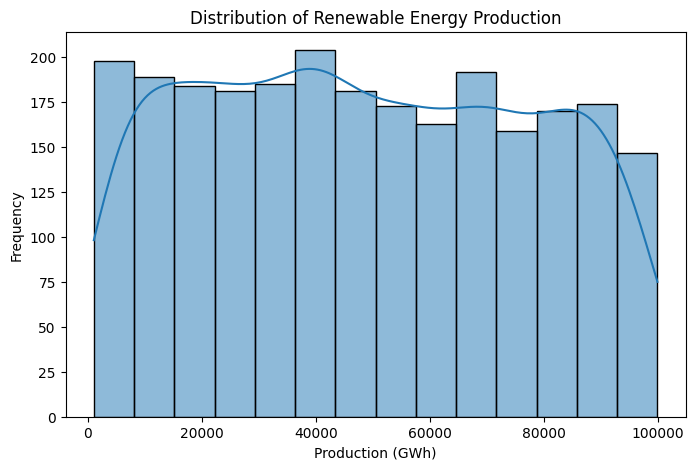

In [6]:
plt.figure(figsize=(8,5))

sns.histplot(renewable_df["Production (GWh)"], kde=True)

plt.title("Distribution of Renewable Energy Production")
plt.xlabel("Production (GWh)")
plt.ylabel("Frequency")

plt.show()

## Box Plot

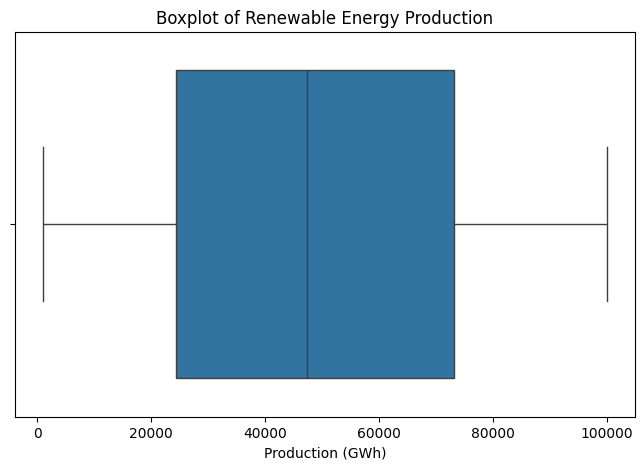

In [7]:
plt.figure(figsize=(8,5))

sns.boxplot(x=renewable_df["Production (GWh)"])

plt.title("Boxplot of Renewable Energy Production")

plt.show()

## Scatter Plot

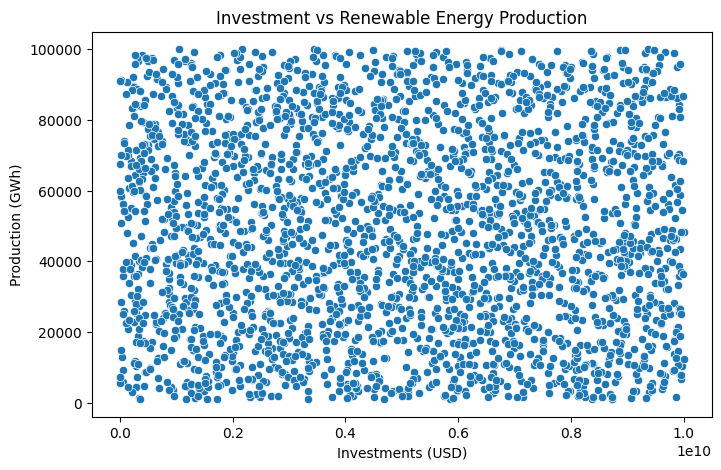

In [8]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Investments (USD)",
    y="Production (GWh)",
    data=renewable_df
)

plt.title("Investment vs Renewable Energy Production")

plt.show()

## Count Plot

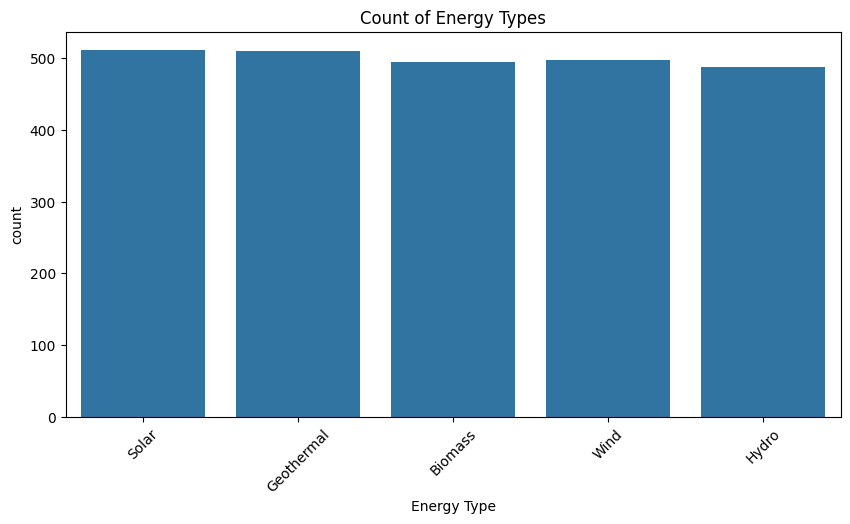

In [9]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="Energy Type",
    data=renewable_df
)

plt.xticks(rotation=45)

plt.title("Count of Energy Types")

plt.show()

## Correlation Heatmap

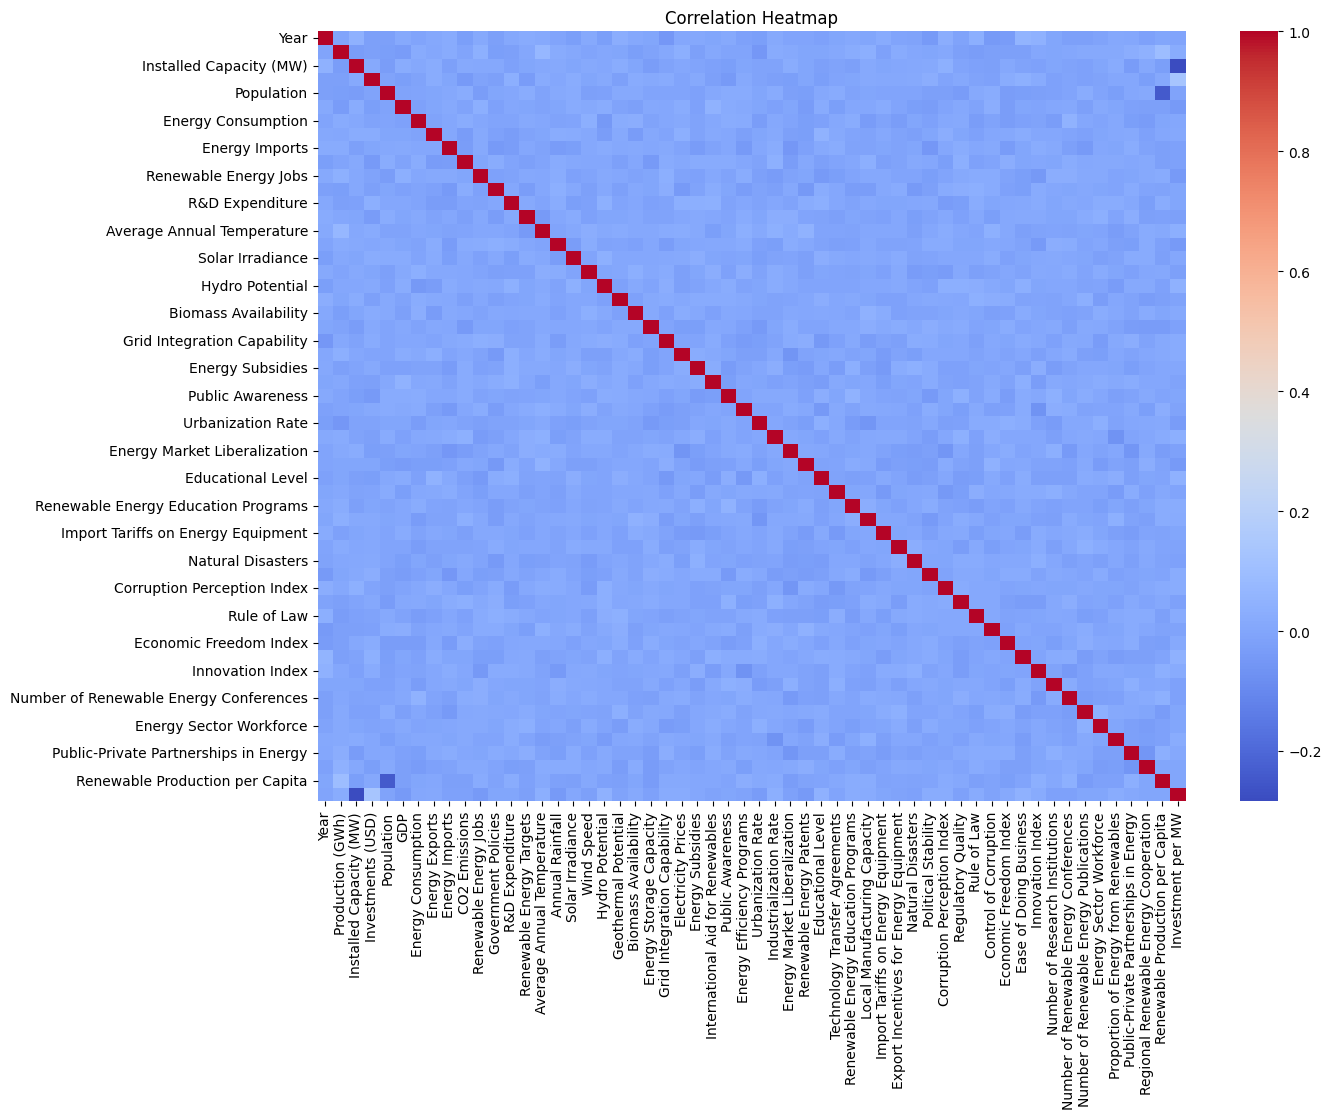

In [10]:
plt.figure(figsize=(14,10))

corr = renewable_df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")

plt.show()

# **Scaling**

In [11]:
scaler = StandardScaler()

numeric_columns = renewable_df.select_dtypes(include=np.number).columns

renewable_df[numeric_columns] = scaler.fit_transform(
    renewable_df[numeric_columns]
)

renewable_df.head()

,Country,Year,Energy Type,Production (GWh),Installed Capacity (MW),Investments (USD),Population,GDP,Energy Consumption,Energy Exports,...,Innovation Index,Number of Research Institutions,Number of Renewable Energy Conferences,Number of Renewable Energy Publications,Energy Sector Workforce,Proportion of Energy from Renewables,Public-Private Partnerships in Energy,Regional Renewable Energy Cooperation,Renewable Production per Capita,Investment per MW
0,USA,-0.063475,Solar,1.293848,-1.336954,0.223885,0.727573,1.322446,-0.432614,1.489679,...,0.923711,1.196601,0.850974,0.479658,0.032820,-0.824427,0.976281,-0.948523,-0.129962,0.196731
1,Australia,-0.498630,Geothermal,-0.936576,1.267494,-1.492624,0.657240,-0.635175,0.947555,-1.678631,...,-0.055102,0.315207,-0.395935,1.656535,1.613874,1.564895,-1.024295,1.054271,-0.176096,-0.247343
2,Canada,0.226629,Biomass,1.600817,-1.296200,0.415493,-1.671894,0.963779,-0.525102,0.520446,...,0.593959,-1.336141,-1.504299,-1.620047,-0.599684,0.608794,0.976281,-0.948523,4.765778,0.193784
3,Japan,-0.208526,Biomass,1.412684,1.067782,1.233484,1.607710,0.587627,0.010771,0.003961,...,-1.592817,-0.572941,-1.642844,0.947147,0.013777,-0.553106,-1.024295,-0.948523,-0.144872,-0.159552
4,China,0.951887,Solar,1.572078,0.406104,0.044946,1.723593,-0.247266,1.109838,0.449500,...,-1.392811,1.649118,0.643156,-0.020800,-1.071840,0.337504,0.976281,-0.948523,-0.144133,-0.180110


# **Encoding**

In [14]:
categorical_cols = renewable_df.select_dtypes(include="object").columns

renewable_df = pd.get_dummies(
    renewable_df,
    columns=categorical_cols,
    drop_first=True
)

print(renewable_df.head())

       Year  Production (GWh)  Installed Capacity (MW)  Investments (USD)  \
0 -0.063475          1.293848                -1.336954           0.223885   
1 -0.498630         -0.936576                 1.267494          -1.492624   
2  0.226629          1.600817                -1.296200           0.415493   
3 -0.208526          1.412684                 1.067782           1.233484   
4  0.951887          1.572078                 0.406104           0.044946   

   Population       GDP  Energy Consumption  Energy Exports  Energy Imports  \
0    0.727573  1.322446           -0.432614        1.489679       -1.301098   
1    0.657240 -0.635175            0.947555       -1.678631        0.963755   
2   -1.671894  0.963779           -0.525102        0.520446       -0.337062   
3    1.607710  0.587627            0.010771        0.003961       -0.305894   
4    1.723593 -0.247266            1.109838        0.449500       -1.144503   

   CO2 Emissions  ...  Country_France  Country_Germany  Countr

# **Selecting Features**

In [16]:
X = renewable_df.drop("Production (GWh)", axis=1)

y = renewable_df["Production (GWh)"]

# **Train Test Split**

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)

print("Testing Shape:", X_test.shape)

Training Shape: (2000, 68)
Testing Shape: (500, 68)


# **Linear Regression**

In [18]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

# **Prediction**

In [19]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[-0.10283314  0.22680006  0.32149746  0.20741103 -0.1070443  -0.0941848
  0.05038    -0.24592333 -0.11637298 -0.22272848]


# **Evaluation**

In [20]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error :", mae)

print("Mean Squared Error :", mse)

print("Root Mean Squared Error :", rmse)

print("R2 Score :", r2)

Mean Absolute Error : 0.8746013946471466
Mean Squared Error : 1.0374386189796483
Root Mean Squared Error : 1.018547308169654
R2 Score : -0.026185504698269524


# **Comparison between Actual and Predicted**

In [21]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(15)

,Actual,Predicted
1447,0.153273,-0.102833
1114,-0.986568,0.226800
1064,-0.119201,0.321497
2287,-1.448470,0.207411
1537,0.319848,-0.107044
668,0.561315,-0.094185
1583,-1.555362,0.050380
2404,-1.057233,-0.245923
497,-0.973556,-0.116373
2480,0.735561,-0.222728


# **Regression Plot**

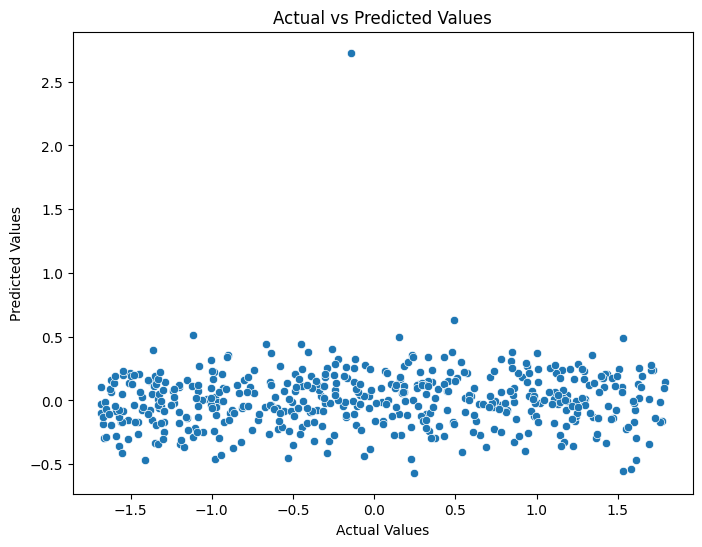

In [22]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_test,
    y=y_pred
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted Values")

plt.show()

# **Model Evaluation**

The Linear Regression model was trained to predict **Renewable Energy Production (GWh)** using various environmental, economic, and energy-related features.

### **Evaluation Metrics**

- **Mean Absolute Error (MAE):** Measures the average absolute difference between the predicted and actual values. Lower values indicate better prediction accuracy.
- **Mean Squared Error (MSE):** Measures the average squared difference between predicted and actual values. It penalizes larger errors more heavily.
- **Root Mean Squared Error (RMSE):** Represents the average prediction error in the same units as the target variable. A lower RMSE indicates better model performance.
- **R² Score:** Indicates how well the model explains the variation in the target variable. A value closer to **1** represents a better fit.

### **Why Linear Regression?**

Linear Regression is suitable because the target variable, **Production (GWh)**, is continuous. The algorithm learns the relationship between input features and renewable energy production to make numerical predictions.

# **Insights**

- Countries with higher investments generally produce more renewable energy.
- Installed capacity has a strong influence on renewable energy production.
- Economic indicators such as GDP and population contribute to energy demand and production.
- Weather-related features (solar irradiance, wind speed, and rainfall) influence renewable energy generation.
- Missing values were replaced using the mean for numerical columns and the mode for categorical columns to preserve the dataset while avoiding unnecessary data loss.
- Feature engineering introduced new variables such as **Renewable Production per Capita** and **Investment per MW**, providing additional insights into energy efficiency and investment effectiveness.
- Numerical features were scaled using **StandardScaler** so that variables with different units contribute equally during model training.
- Categorical variables were encoded to convert textual information into numerical form suitable for machine learning algorithms.
- The trained Linear Regression model can help estimate renewable energy production based on multiple environmental and economic factors.